# Notebook 01 — Primii pași în Julia

Salut, pisoiasul lu' tata! Acest notebook te învață **Julia de la zero**. Nu presupunem că ai mai programat înainte.

**Parcurs:**
1. **Setup** — cum instalezi Julia + Jupyter pe MacBook (sau orice computer).
2. **Primii pași** — ce e Julia, cum rulezi prima ta linie de cod, cum scrii formule.
3. **Fundamente** — variabile, vectori, funcții, structuri, control flow — toate ilustrate cu exemple de chimie.
4. **Exerciții** (cu soluții la final).

**Cum citești notebook-ul:**
- Celulele *markdown* (ca asta) conțin text explicativ.
- Celulele *cod* (cele cu `[ ]:` în stânga) conțin Julia — apasă **`Shift + Enter`** ca să le execuți.
- Toate exemplele sunt rulabile. Modifică valorile și rulează din nou — așa înveți cel mai bine.

> 💡 Toate referințele bibliografice au link la sfârșit, în secțiunea **Referințe**.

## Cap. 0 — Setup

Două lucruri trebuie instalate:
1. **Julia** — limbajul de programare ([julialang.org](https://julialang.org/)).
2. **Jupyter + IJulia** — interfața de notebook în care citești acum.

### Pe macOS (Anastasia)

În Terminal:
```bash
curl -fsSL https://install.julialang.org | sh
```
Sau cu Homebrew dacă îl ai deja:
```bash
brew install juliaup
```
Verifică: `julia --version` → ar trebui să afișeze `julia version 1.12.x`.

### Pe Windows

În PowerShell:
```powershell
winget install julia -s msstore
```
Instalează `juliaup`, managerul oficial de versiuni Julia.

### Instalare IJulia + Jupyter (cross-platform)

După ce ai Julia, deschide REPL (`julia` în terminal) și execută:
```julia
using Pkg
Pkg.add("IJulia")
```
IJulia detectează dacă există deja Jupyter pe sistem; dacă nu, instalează automat o mini-conda dedicată cu Jupyter (~50 MB). Nu poluează alte instalări Python.

### Lansare notebook

Din terminal:
```bash
jupyter notebook
```
Sau din Julia:
```julia
using IJulia
notebook()
```
În browser, deschide `notebooks/01_julia_basics.ipynb`. Verifică în dreapta sus că kernelul selectat e **Julia 1.12** (sau versiunea ta).

**Referințe:** [juliaup](https://github.com/JuliaLang/juliaup) · [IJulia.jl](https://github.com/JuliaLang/IJulia.jl)

## Cap. 1 — Primii pași în Julia

### Ce e un limbaj de programare?

Gândește-te la o **rețetă chimică**: pași clari, în ordine, cu cantități precise. Calculatorul citește astfel de rețete — limbaje de programare — și le execută literal. Diferența: rezultatul nu e un compus, ci o **valoare** sau o **transformare** asupra unor date.

**Julia** [Bezanson et al., 2017] e proiectat pentru calcul științific: rulează rapid (ca C/Fortran), dar arată simplu și citibil. E folosit în chimie computațională, biologie, fizică, finanțe.

### Ce e REPL? Ce e o celulă?

**REPL** = *Read–Eval–Print Loop*. O fereastră interactivă: scrii o expresie, Julia o evaluează, vezi rezultatul, scrii alta. Ca un calculator științific avansat.

Notebook-ul ăsta e un REPL extins: fiecare **celulă** poate fi rulată separat (cu `Shift + Enter`), iar între celulele de cod poți pune text (ca aceasta).

In [1]:
# Cea mai simplă expresie posibilă
1 + 1

2

In [2]:
# Funcții matematice built-in
sqrt(2)

1.4142135623730951

In [3]:
# π e o constantă matematică recunoscută direct
sin(π)

0.0

In [4]:
# Julia descurca numere foarte mari fara probleme
2^60

1152921504606846976

### Atribuire — a da un nume unei valori

Când vrei să folosești același număr de mai multe ori, îi dai un **nume**. Sintaxa: `nume = valoare`.

Julia memorează valoarea, iar de aici încolo, când scrii numele, e ca și cum ai scrie valoarea.

In [5]:
# Masa molară a apei (g/mol)
m_apa = 18.015

18.015

In [6]:
# Cati moli sunt in 36.030 g de apa?
n_moli = 36.030 / m_apa

2.0

### Comentarii și caractere matematice native

**Comentarii:** orice text după `#` pe o linie este ignorat de Julia. Serveşte pentru explicații în cod.

**Caractere Unicode:** Julia acceptă caractere matematice în nume — formulele arată ca pe hârtie. În notebook/REPL tastezi:
- `\alpha` + `Tab` → α
- `\Delta` + `Tab` → Δ
- `\mu` + `Tab` → μ
- `\rho` + `Tab` → ρ
- `\pi` + `Tab` → π

In [7]:
# Constante fizice și chimice cu nume naturale
N_A = 6.022e23   # Avogadro (mol⁻¹)
α = 1.8e4         # coeficient de extincție molară (mol⁻¹·cm⁻¹)
ρ = 0.997         # densitatea apei la 25°C (g/cm³)
Δt = 0.01         # pas de timp

α, ρ, Δt

(18000.0, 0.997, 0.01)

### Pachete — biblioteci de cod gata-făcut

Julia vine cu funcții de bază (numere, vectori, șiruri). Pentru lucruri specializate — algebră liniară avansată, statistică, ploturi, hypergraphuri — folosești **pachete**.

Analogie chimie: e ca un reactiv specializat pe care îl scoți din dulap doar când ai nevoie.

Doi pași:
1. **Instalare** (o singură dată per sistem): `using Pkg; Pkg.add("NumePachet")`
2. **Folosire** (la fiecare sesiune): `using NumePachet`

În notebook-ul ăsta vom folosi **`Plots.jl`** pentru câteva grafice (vezi capitolul 2). În notebook-urile următoare vom adăuga `HyperGraphs.jl`, `OrdinaryDiffEq.jl`, `Flux.jl`.

## Cap. 2 — Fundamente Julia

### 2.1 Vectori — liste ordonate de valori

Un **vector** e o secvență ordonată de valori. Sintaxa: paranteze pătrate, valori separate prin virgulă.

In [8]:
# Masele atomice (u) ale primelor 4 elemente
masse_atomice = [1.008, 4.003, 6.941, 9.012]

4-element Vector{Float64}:
 1.008
 4.003
 6.941
 9.012

In [9]:
length(masse_atomice)   # câte elemente

4

### Indexare — accesul la un element

Pentru a obține un element dintr-un vector, folosim **paranteze pătrate cu poziția**.

> ⚠️ **Atenție:** în Julia indexarea începe de la **1** (nu de la 0). Adică `v[1]` e primul element.

In [10]:
masse_atomice[1]     # primul element — hidrogen

1.008

In [11]:
masse_atomice[end]   # ultimul element — `end` e cuvant rezervat

9.012

**🎨 Hai să-l și vedem.** Folosim primul pachet din proiectul nostru — `Plots.jl` — pentru un grafic bar:

   Resolving package versions...


     Project No packages added to or removed from `C:\Users\danmu\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\danmu\.julia\environments\v1.12\Manifest.toml`


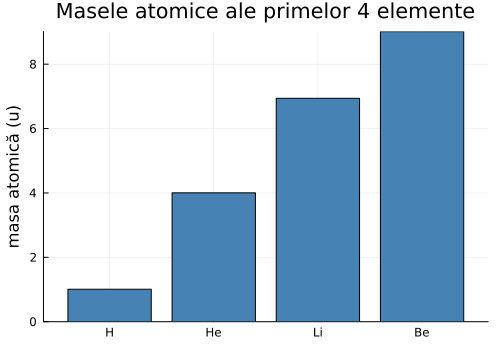

In [12]:
using Pkg; Pkg.add("Plots")   # instalare o data
using Plots

bar(["H", "He", "Li", "Be"], masse_atomice,
    legend=false, ylabel="masa atomică (u)",
    title="Masele atomice ale primelor 4 elemente",
    color=:steelblue, size=(500, 350))

### 2.2 Broadcasting — același lucru pentru fiecare element

Dacă vrei să **înmulțești fiecare element cu 2** (sau să aplici orice funcție pe toate), nu ai nevoie de o buclă. Pui un **punct** înainte de operator sau funcție.

Sintaxa: `vector .* 2`, `sin.(vector)`, `log10.(vector)`.

Asta se cheamă **broadcasting** — punctul "distribuie" operația peste fiecare element.

In [13]:
# Dublarea masei (utila pentru calcule cu dimeri, de exemplu)
masse_atomice .* 2

4-element Vector{Float64}:
  2.016
  8.006
 13.882
 18.024

In [14]:
# log10 aplicat pe fiecare element
log10.(masse_atomice)

4-element Vector{Float64}:
 0.003460532109506489
 0.6023855901051052
 0.8414220444023593
 0.9548211830517932

### 2.3 Matrici — tablouri bidimensionale

O **matrice** e un tabel de numere — rânduri și coloane. Sintaxa: paranteze pătrate, valori separate prin spațiu (pe coloană), punct-virgulă între rânduri.

**Exemplu chimic — matricea de stoichiometrie.** Fiecare rând = un compus, fiecare coloană = o reacție. Valorile: coeficienții stoichiometrici (negativ = consumat, pozitiv = produs).

Reacțiile:
- $2H_2 + O_2 \rightarrow 2H_2O$ (combustia hidrogenului)
- $CH_4 + 2O_2 \rightarrow CO_2 + 2H_2O$ (combustia metanului)

Compuși (ordinea rândurilor): $H_2, O_2, H_2O, CH_4, CO_2$.

In [15]:
# Coloana 1 = reactia 1; coloana 2 = reactia 2
S = [-2   0;     # H2
     -1  -2;     # O2
      2   2;     # H2O
      0  -1;     # CH4
      0   1]     # CO2

size(S)   # (rânduri, coloane)

(5, 2)

**🎨 Matricea ca heatmap** — semnele (negativ = roșu, pozitiv = albastru) devin imediat lizibile:

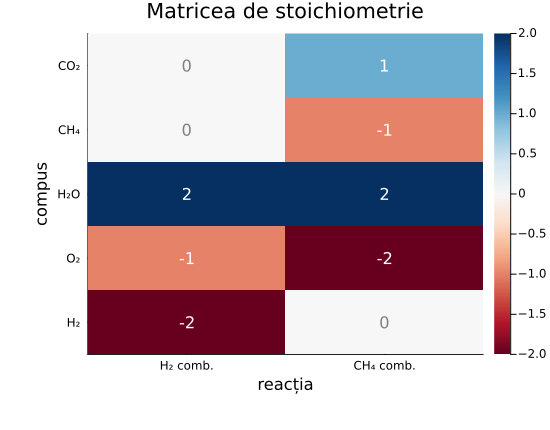

In [16]:
p_S = heatmap(S, c=:RdBu, clim=(-2, 2),
              xlabel="reacția", ylabel="compus",
              xticks=(1:2, ["H₂ comb.", "CH₄ comb."]),
              yticks=(1:5, ["H₂", "O₂", "H₂O", "CH₄", "CO₂"]),
              title="Matricea de stoichiometrie",
              size=(550, 430),
              left_margin=8Plots.mm, bottom_margin=8Plots.mm)
for i in 1:size(S,1), j in 1:size(S,2)
    annotate!(p_S, j, i, text(string(S[i,j]), 11, S[i,j] == 0 ? :gray : :white))
end
p_S

### 2.4 Funcții — cod reutilizabil

O **funcție** primește unul sau mai mulți parametri, face un calcul, returnează un rezultat. Două sintaxe:

**Forma scurtă** (pentru funcții simple, o expresie):
```julia
f(x) = x^2
```

**Forma bloc** (mai multe linii):
```julia
function nume_funcție(parametri)
    # cod
    return rezultat
end
```

In [17]:
# pH-ul unei soluții, dată concentrația ionilor H⁺ (forma scurta)
pH(H) = -log10(H)

# Test: HCl 0.01 M
pH(0.01)

2.0

**🎨 Curba pH-ului** — funcția `pH` aplicată pe un interval de concentrații (notează scala logaritmică pe axa x):

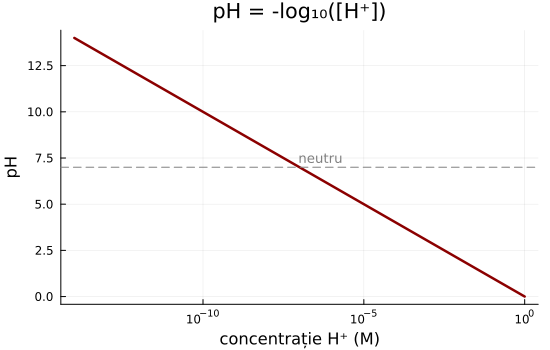

In [18]:
c_range = 10 .^ range(-14, 0; length=200)   # de la 10⁻¹⁴ la 1 M
plot(c_range, pH.(c_range),
     xscale=:log10, lw=2.5, color=:darkred,
     xlabel="concentrație H⁺ (M)", ylabel="pH",
     title="pH = -log₁₀([H⁺])", legend=false,
     size=(550, 350))
hline!([7], ls=:dash, color=:gray)
annotate!(1e-7, 7.5, text("neutru", 9, :gray, :left))

In [19]:
# Diluție — forma bloc
function concentratie_finala(c_initial, V_initial, V_final)
    return c_initial * V_initial / V_final
end

# 25 mL de NaOH 1.0 M diluat la 100 mL total → concentratia finala?
concentratie_finala(1.0, 25e-3, 100e-3)

0.25

### 2.5 Structuri — tipuri proprii de date

Câteodată o singură valoare nu e suficientă pentru a descrie ceva. Un **atom** are simbol, masă, număr atomic. O **moleculă** are mai mulți atomi.

Folosim `struct` pentru a defini un tip propriu care grupează mai multe câmpuri.

In [20]:
struct Atom
    simbol::Symbol     # simbolul chimic, ex. :H, :O, :C
    masa::Float64      # masa atomică (u)
    numar_atomic::Int  # Z
end

# Câțiva atomi (creare = numele structurii + valorile în ordine)
H = Atom(:H, 1.008, 1)
O = Atom(:O, 15.999, 8)
C = Atom(:C, 12.011, 6)

H, O, C

(Atom(:H, 1.008, 1), Atom(:O, 15.999, 8), Atom(:C, 12.011, 6))

In [21]:
# Accesul la câmpuri: nume_obiect.nume_camp
H.masa, O.simbol, C.numar_atomic

(1.008, :O, 6)

### 2.6 Aceeași funcție, comportament adaptat la tip (*multiple dispatch*)

În Julia poți defini **aceeași funcție de mai multe ori**, fiecare versiune pentru un alt tip de parametru. Julia alege automat versiunea potrivită la apel.

Conceptul ăsta se cheamă **multiple dispatch** și e o caracteristică distinctivă a Julia. Nu e nimic complicat — pur și simplu "o funcție cu mai multe înfățișări".

Sintaxa: `nume_funcție(parametru::Tip) = ...` — adăugăm `::Tip` la parametru ca să spunem "versiunea asta e pentru tipul X".

In [22]:
# Versiunea pentru un singur atom: întoarce masa atomului
masa(a::Atom) = a.masa

# Versiunea pentru o moleculă (vector de atomi): suma maselor
masa(atomi::Vector{Atom}) = sum(a.masa for a in atomi)

masa (generic function with 2 methods)

In [23]:
# Test pe un singur atom
masa(H)

1.008

In [24]:
# Test pe apă: H2O = doi H + un O
apa = [H, H, O]
masa(apa)

18.015

### 2.7 Decizii și repetare

Codul nu rulează mereu liniar. Două structuri esențiale:

- **`if ... elseif ... else ... end`** — execută cod *condiționat*.
- **`for ... end`** — *repetă* cod pentru fiecare element dintr-un vector.

In [25]:
function clasifica_solutie(pH_val)
    if pH_val < 7
        return "acidă"
    elseif pH_val > 7
        return "bazică"
    else
        return "neutră"
    end
end

clasifica_solutie(2.5)

"acidă"

In [26]:
# Calculam pH-ul pentru mai multe concentratii
concentratii = [1e-1, 1e-3, 1e-7, 1e-10]

for c in concentratii
    println("c(H⁺) = ", c, "  →  pH = ", round(pH(c); digits=2))
end

c(H⁺) = 0.1  →  pH = 1.0
c(H⁺) = 0.001  →  pH = 3.0
c(H⁺) = 1.0e-7  →  pH = 7.0
c(H⁺) = 1.0e-10  →  pH = 10.0


### 2.8 Comenzi speciale: macro-uri

Comenzile care încep cu `@` se cheamă **macro-uri**. Două ne sunt utile la început:

- **`@show x`** — afișează `x = valoare` (util pentru debugging).
- **`@time expresie`** — măsoară cât durează un calcul.

Le numim "macro-uri" pentru terminologie corectă; mecanica internă o vei vedea mai târziu.

In [27]:
x = 42
@show x;

x = 42


In [28]:
# Cat dureaza sa sumam un milion de numere?
@time sum(1:1_000_000)

  0.000000 seconds


500000500000

## Exerciții

Încearcă fiecare exercițiu. **Scrie-ți întâi propria soluție** în celulele goale, apoi compară cu soluțiile de la final.

### Exercițiul 1 — Masa medie

Definește un vector cu masele molare ale apei (18.015), etanolului (46.07) și acetonei (58.08). Calculează masa medie.

*Hint:* funcțiile `sum` și `length` îți pot folosi.

In [29]:
# Scrie aici solutia ta — Exercitiul 1


### Exercițiul 2 — pH în lanț

Folosește funcția `pH` definită mai sus pentru un vector cu concentrații `[1e-2, 1e-5, 1e-7, 1e-9, 1e-12]`. Afișează rezultatele formatat (`c = 0.01, pH = 2.0`).

*Hint:* o buclă `for` cu `println`, sau broadcasting cu `pH.()`.

In [30]:
# Scrie aici solutia ta — Exercitiul 2


### Exercițiul 3 — Moleculă custom

1. Definește un `struct Molecule` cu două câmpuri: `atomi::Vector{Atom}` și `nume::String`.
2. Definește funcția `masa_totala(m::Molecule)` care întoarce suma maselor atomilor.
3. Construiește molecula CH₄ (metan, 1 C + 4 H) și calculează-i masa.

In [31]:
# Scrie aici solutia ta — Exercitiul 3


### Exercițiul 4 — Conservarea masei

Pentru reacția $2H_2 + O_2 \rightarrow 2H_2O$:
- Vectorul coeficienților stoichiometrici (negativ reactanți, pozitiv produși): `s = [-2, -1, 2]`.
- Masele molare ale H₂, O₂, H₂O: `m = [2.016, 31.998, 18.015]` (g/mol).

Verifică prin calcul că masa totală se conservă (suma `s .* m` trebuie să fie aproape de 0).

In [32]:
# Scrie aici solutia ta — Exercitiul 4


## Soluții

*Nu citi înainte să fi încercat singură.*

In [33]:
# Solutia 1 — masa medie
masse = [18.015, 46.07, 58.08]
masa_medie = sum(masse) / length(masse)

40.72166666666667

In [34]:
# Solutia 2 — pH in lant (cu bucla for)
concentratii_ex = [1e-2, 1e-5, 1e-7, 1e-9, 1e-12]
for c in concentratii_ex
    println("c = ", c, ", pH = ", round(pH(c); digits=2))
end

c = 0.01, pH = 2.0
c = 1.0e-5, pH = 5.0
c = 1.0e-7, pH = 7.0
c = 1.0e-9, pH = 9.0
c = 1.0e-12, pH = 12.0


In [35]:
# Solutia 3 — molecula custom
struct Molecule
    atomi::Vector{Atom}
    nume::String
end

masa_totala(m::Molecule) = sum(a.masa for a in m.atomi)

# Metan: 1 C + 4 H
CH4 = Molecule([C, H, H, H, H], "metan")
masa_totala(CH4)

16.042999999999996

In [36]:
# Solutia 4 — conservarea masei
s = [-2, -1, 2]
m = [2.016, 31.998, 18.015]
sum(s .* m)   # ≈ 0 ⇒ masa se conserva

0.0

## Ce ai învățat în acest notebook

- ✅ Cum rulezi cod Julia într-un notebook Jupyter.
- ✅ Atribuire de variabile, comentarii, caractere Unicode native (α, Δ, ρ, …).
- ✅ Vectori, matrici, **indexare începe de la 1**, broadcasting cu `.`.
- ✅ Funcții (forma scurtă și forma bloc).
- ✅ Structuri proprii (`struct`) pentru tipuri custom.
- ✅ **Multiple dispatch** — aceeași funcție, mai multe versiuni după tip.
- ✅ Control flow (`if`/`elseif`/`else`, `for`) și macro-uri uzuale (`@show`, `@time`).

**Următor pas:** notebook 02, în care intrăm pe **hypergraphuri** — atât teoretic (Berge 1973, Ouvrard 2020) cât și practic (pachetul `HyperGraphs.jl` aplicat la rețele biochimice, după Diaz & Stumpf 2022).

## Referințe

- **Bezanson, J., Edelman, A., Karpinski, S., & Shah, V. B. (2017).** Julia: A fresh approach to numerical computing. *SIAM Review*, 59(1), 65–98. [DOI: 10.1137/141000671](https://doi.org/10.1137/141000671)
- **Julia official documentation** — <https://docs.julialang.org/>
- **Think Julia: How to Think Like a Computer Scientist** (Lauwens & Downey, manual gratuit) — <https://benlauwens.github.io/ThinkJulia.jl/latest/book.html>
- **Julia Academy** (cursuri video gratuite) — <https://juliaacademy.com/>
- **juliaup** (version manager Julia) — <https://github.com/JuliaLang/juliaup>
- **IJulia.jl** (kernel Jupyter pentru Julia) — <https://github.com/JuliaLang/IJulia.jl>